In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    RocCurveDisplay
)

from xgboost import XGBClassifier

In [44]:
df = pd.read_csv("/content/creditcard.csv")

print("Shape of dataset:", df.shape)
print(df.head())
print(df.columns)

Shape of dataset: (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

 

In [ ]:
print(df.isnull().sum().sum())

0


In [ ]:
df.dropna(inplace=True)

In [ ]:
print(df["Class"].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


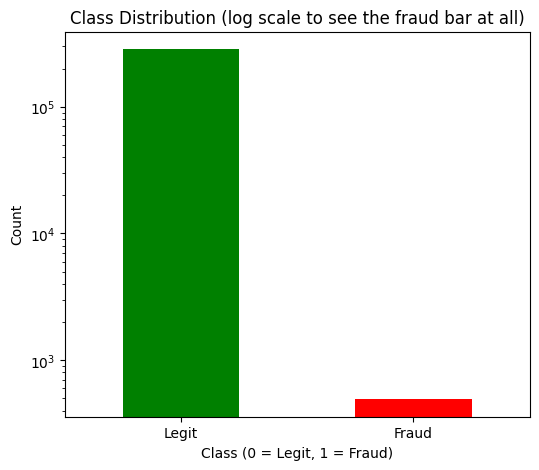

In [32]:
plt.figure(figsize=(6, 5))
df['Class'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.xlabel('Class (0 = Legit, 1 = Fraud)')
plt.ylabel('Count')
plt.title('Class Distribution (log scale to see the fraud bar at all)')
plt.yscale('log')
plt.xticks([0, 1], ['Legit', 'Fraud'], rotation=0)
plt.show()

In [33]:
df['Amount'].describe()

,Amount
count,284807.000000
mean,88.349619
std,250.120109
min,0.000000
25%,5.600000
50%,22.000000
75%,77.165000
max,25691.160000


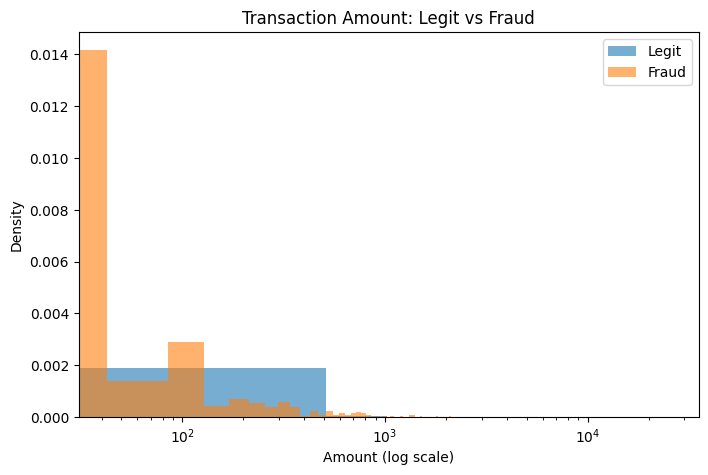

In [34]:
plt.figure(figsize=(8, 5))
plt.hist(df[df['Class'] == 0]['Amount'], bins=50, alpha=0.6, label='Legit', density=True)
plt.hist(df[df['Class'] == 1]['Amount'], bins=50, alpha=0.6, label='Fraud', density=True)
plt.xscale('log')
plt.xlabel('Amount (log scale)')
plt.ylabel('Density')
plt.title('Transaction Amount: Legit vs Fraud')
plt.legend()
plt.show()

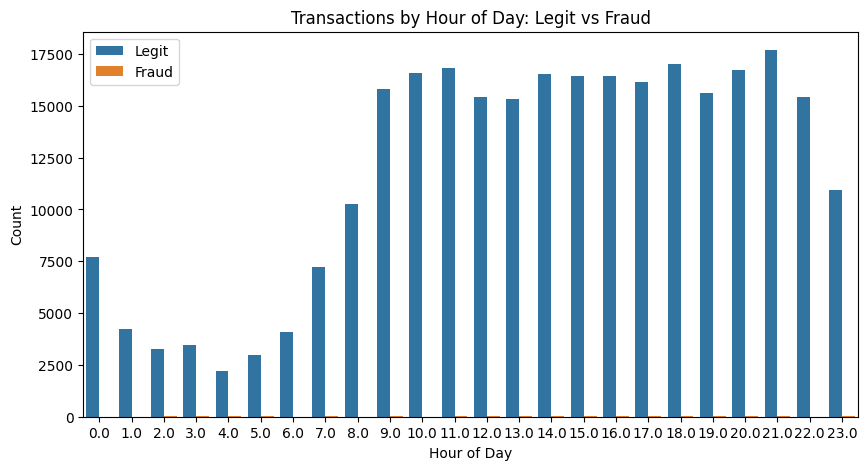

In [35]:
df['hour_of_day'] = (df['Time'] // 3600) % 24

plt.figure(figsize=(10, 5))
sns.countplot(x='hour_of_day', hue='Class', data=df)
plt.xlabel('Hour of Day')
plt.ylabel('Count')
plt.title('Transactions by Hour of Day: Legit vs Fraud')
plt.legend(['Legit', 'Fraud'])
plt.show()

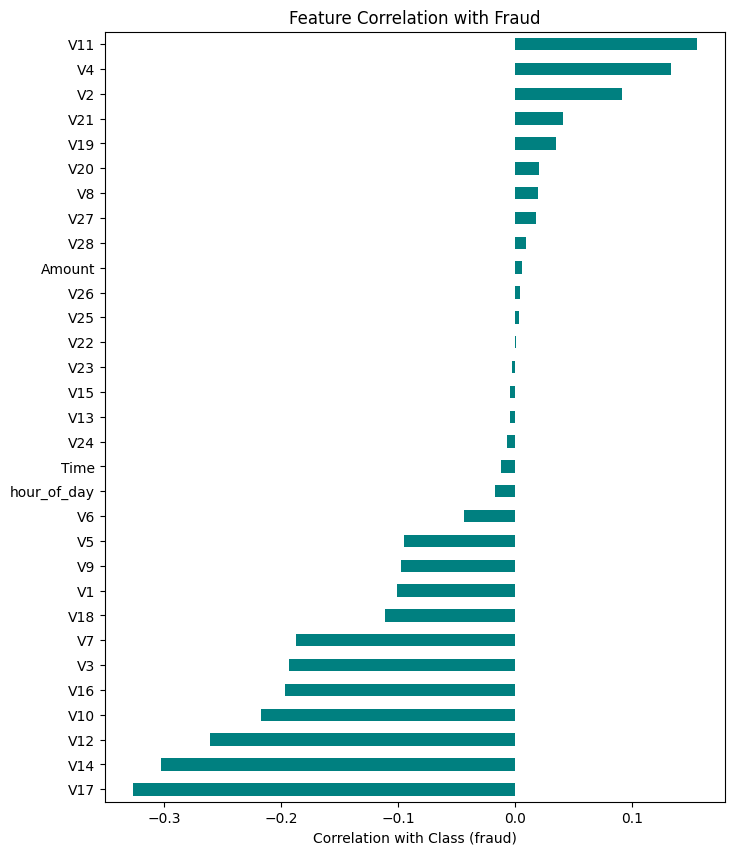

In [40]:
correlations = df.corr()['Class'].drop('Class').sort_values()

plt.figure(figsize=(8, 10))
correlations.plot(kind='barh', color='teal')
plt.xlabel('Correlation with Class (fraud)')
plt.title('Feature Correlation with Fraud')
plt.show()

Most fraud-correlated features: ['V17', 'V14', 'V12', 'V10']


/tmp/ipykernel_3134/939955327.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Legit', 'Fraud'])
/tmp/ipykernel_3134/939955327.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Legit', 'Fraud'])
/tmp/ipykernel_3134/939955327.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Legit', 'Fraud'])
/tmp/ipykernel_3134/939955327.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Legit', 'Fraud'])


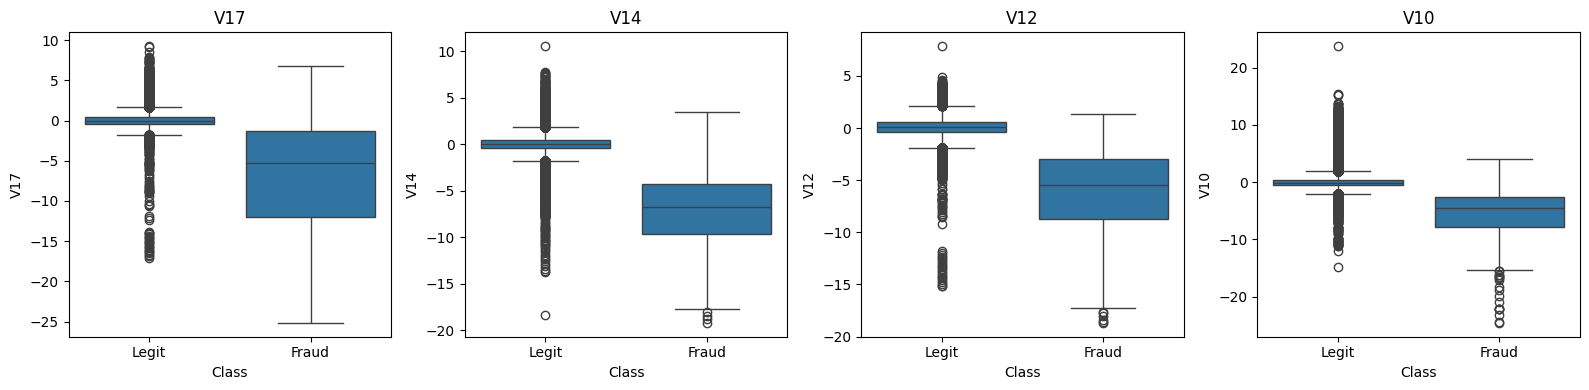

In [41]:
top_features = correlations.abs().sort_values(ascending=False).head(4).index.tolist()
print("Most fraud-correlated features:", top_features)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, feature in enumerate(top_features):
    sns.boxplot(x='Class', y=feature, data=df, ax=axes[i])
    axes[i].set_xticklabels(['Legit', 'Fraud'])
    axes[i].set_title(feature)
plt.tight_layout()
plt.show()

In [45]:
df_cleaned = df.drop(columns=['Time'])

scaler = StandardScaler()
df_cleaned['Amount'] = scaler.fit_transform(df_cleaned[['Amount']])

df_cleaned.head(5)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244964,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342475,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.160686,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.140534,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073403,0


In [46]:
X = df_cleaned.drop('Class', axis=1)
y = df_cleaned['Class']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nClass balance:")
print(y.value_counts(normalize=True))

Features shape: (284807, 29)
Target shape: (284807,)

Class balance:
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"\nTraining target distribution:")
print(y_train.value_counts())

Training set size: (227845, 29)
Test set size: (56962, 29)

Training target distribution:
Class
0    227451
1       394
Name: count, dtype: int64


In [48]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

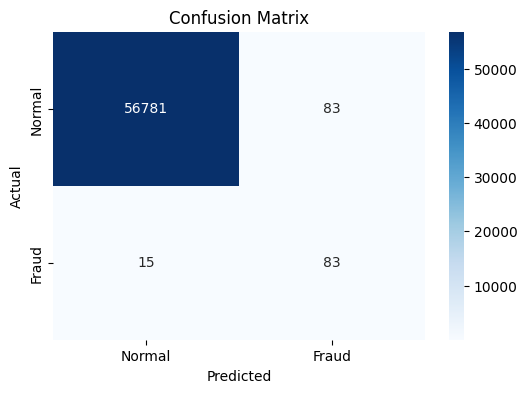

In [50]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [51]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))


Classification Report:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.50      0.85      0.63        98

    accuracy                           1.00     56962
   macro avg       0.75      0.92      0.81     56962
weighted avg       1.00      1.00      1.00     56962



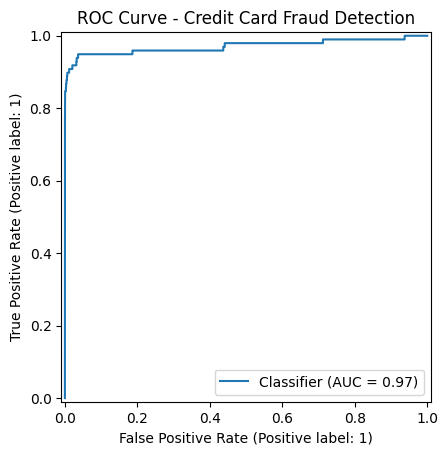

ROC-AUC: 0.9707


In [56]:
y_probability = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_probability)

RocCurveDisplay.from_predictions(y_test, y_probability)
plt.title("ROC Curve - Credit Card Fraud Detection")
plt.show()

print(f"ROC-AUC: {roc_auc:.4f}")

In [57]:
print("----- Model Performance -----")

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

----- Model Performance -----
Accuracy : 0.9983
Precision: 0.5
Recall   : 0.8469
F1 Score : 0.6288
ROC-AUC  : 0.9707
